In [5]:
# Cell 1: Import libraries and setup for relationship analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.stats import chi2_contingency, pearsonr
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
import re
import warnings
warnings.filterwarnings('ignore')

# Set plotting style for Norwegian grid company analysis
plt.style.use('default')
sns.set_palette("Set2")


In [6]:
# Cell 2: Load and prepare data with focus on key factors
def load_and_prepare_key_factors_data(csv_file_path, sps_file_path):
    """
    Load data and identify key factor variables for relationship analysis
    """
    # Load data
    df = pd.read_csv(csv_file_path, delimiter=';', encoding='utf-8')
    
    # Parse SPSS labels (using previous function)
    variable_labels, value_labels = parse_spss_syntax(sps_file_path)
    
    # Define key factor groups based on your research questions
    key_factors = {
        'decision_types': {
            'main_vars': ['decision_type.1', 'decision_type.2', 'decision_type.3', 
                         'decision_type.4', 'decision_type.5', 'decision_type.6'],
            'involvement_vars': ['decision_type1_involvement.level', 'decision_type2_involvement.level',
                               'decision_type3_involvement.level', 'decision_type4_involvement.level'],
            'subtype_vars': [col for col in df.columns if 'decision_type' in col and 'subtype' in col]
        },
        
        'methods_tools': {
            'analysis_types': ['analyze_type.1', 'analyze_type.2', 'analyze_type.3', 
                             'analyze_type.4', 'analyze_type.5'],
            'simulation_types': ['simulation_type.1', 'simulation_type.2', 'simulation_type.3',
                               'simulation_type.4', 'simulation_type.5', 'simulation_type.6'],
            'software_types': [col for col in df.columns if col.startswith('software_type.') 
                             and col != 'software_type.42'],  # Exclude "no software"
            'indicators': [col for col in df.columns if col.startswith('indicators_type.')]
        },
        
        'uncertainty_handling': {
            'analysis_uncertainty': ['analyze_type1_uncertainty.1', 'analyze_type1_uncertainty.2',
                                   'analyze_type1_uncertainty.3', 'analyze_type1_uncertainty.4'],
            'simulation_uncertainty': ['simulation_uncertainty.1', 'simulation_uncertainty.2',
                                     'simulation_uncertainty.3', 'simulation_uncertainty.4',
                                     'simulation_uncertainty.5'],
            'modeling_uncertainty': ['analyze_type3_uncertainty.1', 'analyze_type3_uncertainty.2',
                                   'analyze_type3_uncertainty.3', 'analyze_type3_uncertainty.4']
        },
        
        'barriers': {
            'software_barriers': ['software_barrieres.1', 'software_barrieres.2', 'software_barrieres.3',
                                'software_barrieres.4', 'software_barrieres.5', 'software_barrieres.6'],
            'indicator_barriers': ['indicators_barriers.1', 'indicators_barriers.2', 'indicators_barriers.3',
                                 'indicators_barriers.4', 'indicators_barriers.5', 'indicators_barriers.6']
        }
    }
    
    return df, variable_labels, value_labels, key_factors

def parse_spss_syntax(sps_file_path):
    """Parse SPSS syntax file to extract variable labels and value labels"""
    with open(sps_file_path, 'r', encoding='utf-8') as f:
        sps_content = f.read()
    
    # Extract variable labels
    variable_labels = {}
    var_label_pattern = r"VARIABLE LABELS\s+(\S+)\s+'([^']+)'"
    for match in re.finditer(var_label_pattern, sps_content):
        var_name = match.group(1)
        var_label = match.group(2)
        variable_labels[var_name] = var_label
    
    # Extract value labels
    value_labels = {}
    value_label_pattern = r"VALUE LABELS\s+(\S+)\s+((?:\s+\d+\s+'[^']+'\s*)+)\."
    
    for match in re.finditer(value_label_pattern, sps_content, re.MULTILINE):
        var_name = match.group(1)
        values_block = match.group(2)
        value_pairs = re.findall(r"(\d+)\s+'([^']+)'", values_block)
        value_labels[var_name] = {int(code): label.strip() for code, label in value_pairs}
    
    return variable_labels, value_labels
# Load data
csv_file_path = 'Data/results.csv' 
sps_file_path = 'Data/syntax.sps'  

df, variable_labels, value_labels, key_factors = load_and_prepare_key_factors_data(
    csv_file_path, sps_file_path
)

print(f"Dataset loaded: {df.shape}")
print(f"Key factor groups identified: {list(key_factors.keys())}")


Dataset loaded: (24, 231)
Key factor groups identified: ['decision_types', 'methods_tools', 'uncertainty_handling', 'barriers']


In [7]:
# Cell 3: Create aggregated variables for key factors
def create_key_factor_aggregations(df, key_factors):
    """
    Create meaningful aggregated variables for each key factor
    """
    df_analysis = df.copy()
    
    # Decision Types Analysis
    decision_vars = key_factors['decision_types']['main_vars']
    existing_decision_vars = [col for col in decision_vars if col in df.columns]
    if existing_decision_vars:
        df_analysis['decision_diversity'] = df[existing_decision_vars].sum(axis=1)
        df_analysis['is_customer_focused'] = df['decision_type.1'].fillna(0)  # Customer connections
        df_analysis['is_operations_focused'] = df['decision_type.2'].fillna(0)  # Operations planning
        df_analysis['is_planning_focused'] = df['decision_type.3'].fillna(0)  # Network planning
        df_analysis['is_standards_focused'] = df['decision_type.4'].fillna(0)  # Standards setting
    
    # Methods and Tools Analysis
    analysis_vars = [col for col in key_factors['methods_tools']['analysis_types'] if col in df.columns]
    if analysis_vars:
        df_analysis['analysis_method_count'] = df[analysis_vars].sum(axis=1)
        df_analysis['uses_outage_analysis'] = df['analyze_type.1'].fillna(0)
        df_analysis['uses_operations_analysis'] = df['analyze_type.2'].fillna(0)
        df_analysis['uses_modeling'] = df['analyze_type.3'].fillna(0)
    
    simulation_vars = [col for col in key_factors['methods_tools']['simulation_types'] if col in df.columns]
    if simulation_vars:
        df_analysis['simulation_method_count'] = df[simulation_vars].sum(axis=1)
        df_analysis['uses_powerflow'] = df['simulation_type.1'].fillna(0)
        df_analysis['uses_stochastic'] = df['simulation_type.3'].fillna(0)
    
    software_vars = [col for col in key_factors['methods_tools']['software_types'] if col in df.columns]
    if software_vars:
        df_analysis['software_tool_count'] = df[software_vars].sum(axis=1)
        df_analysis['software_diversity'] = (df[software_vars] > 0).sum(axis=1)
    
    # Uncertainty Handling Analysis
    uncertainty_vars = []
    for category in key_factors['uncertainty_handling'].values():
        uncertainty_vars.extend([col for col in category if col in df.columns])
    
    if uncertainty_vars:
        df_analysis['uncertainty_method_count'] = df[uncertainty_vars].sum(axis=1)
        
        # Specific uncertainty approaches
        if 'analyze_type1_uncertainty.1' in df.columns:
            df_analysis['uses_probabilistic'] = df['analyze_type1_uncertainty.1'].fillna(0)
        if 'analyze_type1_uncertainty.2' in df.columns:
            df_analysis['uses_scenarios'] = df['analyze_type1_uncertainty.2'].fillna(0)
        if 'analyze_type1_uncertainty.3' in df.columns:
            df_analysis['uses_historical'] = df['analyze_type1_uncertainty.3'].fillna(0)
    
    # Barriers Analysis
    software_barrier_vars = [col for col in key_factors['barriers']['software_barriers'] if col in df.columns]
    if software_barrier_vars:
        # Convert barrier scale (5=critical, 1=not a barrier) to severity scores
        barrier_df = df[software_barrier_vars].fillna(0)
        df_analysis['software_barrier_severity'] = barrier_df.mean(axis=1)
        df_analysis['has_critical_software_barriers'] = (barrier_df >= 4).any(axis=1).astype(int)
        
        # Specific barrier types
        if 'software_barrieres.2' in df.columns:
            df_analysis['data_quality_barrier'] = df['software_barrieres.2'].fillna(0)
        if 'software_barrieres.4' in df.columns:
            df_analysis['complexity_barrier'] = df['software_barrieres.4'].fillna(0)
        if 'software_barrieres.5' in df.columns:
            df_analysis['tool_support_barrier'] = df['software_barrieres.5'].fillna(0)
    
    return df_analysis

# Create aggregated variables
df_analysis = create_key_factor_aggregations(df, key_factors)

print("Key factor aggregations created:")
new_vars = [col for col in df_analysis.columns if col not in df.columns]
for var in new_vars[:10]:  # Show first 10
    print(f"  • {var}")
if len(new_vars) > 10:
    print(f"  ... and {len(new_vars) - 10} more")


Key factor aggregations created:
  • decision_diversity
  • is_customer_focused
  • is_operations_focused
  • is_planning_focused
  • is_standards_focused
  • analysis_method_count
  • uses_outage_analysis
  • uses_operations_analysis
  • uses_modeling
  • simulation_method_count
  ... and 13 more


In [8]:
# Cell 4: Analyze relationships between decision types and other factors
def analyze_decision_type_relationships(df_analysis, variable_labels):
    """
    Analyze how decision types impact methods, uncertainty handling, and barriers
    """
    print("="*80)
    print("DECISION TYPE IMPACT ANALYSIS")
    print("="*80)
    
    # Decision diversity vs method usage
    if 'decision_diversity' in df_analysis.columns and 'analysis_method_count' in df_analysis.columns:
        correlation = df_analysis[['decision_diversity', 'analysis_method_count', 
                                 'simulation_method_count', 'software_tool_count']].corr()
        
        print("\n📊 DECISION DIVERSITY CORRELATIONS:")
        print("Decision diversity vs:")
        print(f"  • Analysis methods: {correlation.loc['decision_diversity', 'analysis_method_count']:.3f}")
        print(f"  • Simulation methods: {correlation.loc['decision_diversity', 'simulation_method_count']:.3f}")
        print(f"  • Software tools: {correlation.loc['decision_diversity', 'software_tool_count']:.3f}")
    
    # Specific decision type impacts
    decision_types = ['is_customer_focused', 'is_operations_focused', 'is_planning_focused', 'is_standards_focused']
    
    for decision_type in decision_types:
        if decision_type in df_analysis.columns:
            print(f"\n🎯 {decision_type.upper().replace('IS_', '').replace('_', ' ')} IMPACT:")
            
            # Group by decision type involvement
            involved = df_analysis[df_analysis[decision_type] == 1]
            not_involved = df_analysis[df_analysis[decision_type] == 0]
            
            if len(involved) > 0 and len(not_involved) > 0:
                # Method usage comparison
                if 'analysis_method_count' in df_analysis.columns:
                    involved_methods = involved['analysis_method_count'].mean()
                    not_involved_methods = not_involved['analysis_method_count'].mean()
                    print(f"  Analysis methods: {involved_methods:.1f} vs {not_involved_methods:.1f}")
                
                # Uncertainty handling comparison
                if 'uncertainty_method_count' in df_analysis.columns:
                    involved_uncertainty = involved['uncertainty_method_count'].mean()
                    not_involved_uncertainty = not_involved['uncertainty_method_count'].mean()
                    print(f"  Uncertainty methods: {involved_uncertainty:.1f} vs {not_involved_uncertainty:.1f}")
                
                # Barrier severity comparison
                if 'software_barrier_severity' in df_analysis.columns:
                    involved_barriers = involved['software_barrier_severity'].mean()
                    not_involved_barriers = not_involved['software_barrier_severity'].mean()
                    print(f"  Barrier severity: {involved_barriers:.2f} vs {not_involved_barriers:.2f}")

# Run decision type analysis
analyze_decision_type_relationships(df_analysis, variable_labels)


DECISION TYPE IMPACT ANALYSIS

📊 DECISION DIVERSITY CORRELATIONS:
Decision diversity vs:
  • Analysis methods: -0.103
  • Simulation methods: 0.183
  • Software tools: -0.071

🎯 CUSTOMER FOCUSED IMPACT:
  Analysis methods: 2.3 vs 2.6
  Uncertainty methods: 4.7 vs 5.8
  Barrier severity: 2.10 vs 2.35

🎯 OPERATIONS FOCUSED IMPACT:
  Analysis methods: 2.7 vs 2.3
  Uncertainty methods: 5.7 vs 4.8
  Barrier severity: 2.30 vs 2.13

🎯 PLANNING FOCUSED IMPACT:
  Analysis methods: 2.2 vs 3.0
  Uncertainty methods: 4.6 vs 6.8
  Barrier severity: 2.10 vs 2.47

🎯 STANDARDS FOCUSED IMPACT:
  Analysis methods: 2.1 vs 2.8
  Uncertainty methods: 4.9 vs 5.5
  Barrier severity: 2.39 vs 1.92


In [9]:
# Cell 5: Analyze uncertainty handling patterns
def analyze_uncertainty_patterns(df_analysis):
    """
    Analyze how uncertainty handling varies across different contexts
    """
    print("\n" + "="*80)
    print("UNCERTAINTY HANDLING PATTERNS")
    print("="*80)
    
    # Create uncertainty approach profiles
    uncertainty_approaches = ['uses_probabilistic', 'uses_scenarios', 'uses_historical']
    available_approaches = [col for col in uncertainty_approaches if col in df_analysis.columns]
    
    if available_approaches:
        print("\n📈 UNCERTAINTY APPROACH USAGE:")
        for approach in available_approaches:
            usage_rate = df_analysis[approach].mean()
            print(f"  • {approach.replace('uses_', '').title()}: {usage_rate:.1%}")
        
        # Uncertainty approach by decision type
        print("\n🔍 UNCERTAINTY APPROACHES BY DECISION TYPE:")
        decision_types = ['is_customer_focused', 'is_operations_focused', 'is_planning_focused']
        
        for decision_type in decision_types:
            if decision_type in df_analysis.columns:
                involved = df_analysis[df_analysis[decision_type] == 1]
                if len(involved) > 2:  # Need minimum sample
                    print(f"\n  {decision_type.replace('is_', '').replace('_', ' ').title()}:")
                    for approach in available_approaches:
                        usage = involved[approach].mean()
                        print(f"    - {approach.replace('uses_', '').title()}: {usage:.1%}")
    
    # Uncertainty complexity analysis
    if 'uncertainty_method_count' in df_analysis.columns:
        print(f"\n📊 UNCERTAINTY METHOD COMPLEXITY:")
        uncertainty_dist = df_analysis['uncertainty_method_count'].value_counts().sort_index()
        for methods, count in uncertainty_dist.items():
            print(f"  • {int(methods)} methods: {count} respondents ({count/len(df_analysis):.1%})")
        
        # Relationship between uncertainty complexity and barriers
        if 'software_barrier_severity' in df_analysis.columns:
            correlation = df_analysis[['uncertainty_method_count', 'software_barrier_severity']].corr()
            corr_val = correlation.loc['uncertainty_method_count', 'software_barrier_severity']
            print(f"\n🔗 Uncertainty complexity vs barrier severity: {corr_val:.3f}")

# Run uncertainty analysis
analyze_uncertainty_patterns(df_analysis)



UNCERTAINTY HANDLING PATTERNS

📈 UNCERTAINTY APPROACH USAGE:
  • Probabilistic: 33.3%
  • Scenarios: 45.8%
  • Historical: 37.5%

🔍 UNCERTAINTY APPROACHES BY DECISION TYPE:

  Customer Focused:
    - Probabilistic: 26.7%
    - Scenarios: 33.3%
    - Historical: 26.7%

  Operations Focused:
    - Probabilistic: 55.6%
    - Scenarios: 55.6%
    - Historical: 22.2%

  Planning Focused:
    - Probabilistic: 27.8%
    - Scenarios: 33.3%
    - Historical: 22.2%

📊 UNCERTAINTY METHOD COMPLEXITY:
  • 0 methods: 2 respondents (8.3%)
  • 2 methods: 3 respondents (12.5%)
  • 3 methods: 3 respondents (12.5%)
  • 4 methods: 2 respondents (8.3%)
  • 5 methods: 3 respondents (12.5%)
  • 6 methods: 3 respondents (12.5%)
  • 7 methods: 4 respondents (16.7%)
  • 9 methods: 2 respondents (8.3%)
  • 10 methods: 1 respondents (4.2%)
  • 11 methods: 1 respondents (4.2%)

🔗 Uncertainty complexity vs barrier severity: 0.249


In [10]:
# Cell 6: Analyze method-barrier relationships
def analyze_method_barrier_relationships(df_analysis):
    """
    Analyze how methods and tools impact barriers experienced
    """
    print("\n" + "="*80)
    print("METHOD-BARRIER RELATIONSHIP ANALYSIS")
    print("="*80)
    
    # Software tool diversity vs barriers
    if 'software_diversity' in df_analysis.columns and 'software_barrier_severity' in df_analysis.columns:
        correlation = df_analysis[['software_diversity', 'software_barrier_severity']].corr()
        corr_val = correlation.loc['software_diversity', 'software_barrier_severity']
        print(f"\n🔧 Software diversity vs barrier severity: {corr_val:.3f}")
        
        # Group analysis by software usage level
        print(f"\n📊 BARRIERS BY SOFTWARE USAGE LEVEL:")
        df_analysis['software_usage_level'] = pd.cut(df_analysis['software_diversity'], 
                                                    bins=[0, 1, 3, 10], 
                                                    labels=['Low (0-1)', 'Medium (2-3)', 'High (4+)'])
        
        barrier_by_usage = df_analysis.groupby('software_usage_level')['software_barrier_severity'].agg(['mean', 'count'])
        for level, stats in barrier_by_usage.iterrows():
            if stats['count'] > 0:
                print(f"  • {level}: {stats['mean']:.2f} avg severity ({int(stats['count'])} respondents)")
    
    # Specific barrier analysis
    specific_barriers = ['data_quality_barrier', 'complexity_barrier', 'tool_support_barrier']
    available_barriers = [col for col in specific_barriers if col in df_analysis.columns]
    
    if available_barriers:
        print(f"\n🚧 SPECIFIC BARRIER ANALYSIS:")
        
        # Method complexity vs specific barriers
        if 'analysis_method_count' in df_analysis.columns:
            print(f"\n  Method complexity impact:")
            for barrier in available_barriers:
                correlation = df_analysis[['analysis_method_count', barrier]].corr()
                corr_val = correlation.loc['analysis_method_count', barrier]
                barrier_name = barrier.replace('_barrier', '').replace('_', ' ').title()
                print(f"    - {barrier_name}: {corr_val:.3f}")
        
        # Software usage vs specific barriers
        if 'software_tool_count' in df_analysis.columns:
            print(f"\n  Software usage impact:")
            for barrier in available_barriers:
                correlation = df_analysis[['software_tool_count', barrier]].corr()
                corr_val = correlation.loc['software_tool_count', barrier]
                barrier_name = barrier.replace('_barrier', '').replace('_', ' ').title()
                print(f"    - {barrier_name}: {corr_val:.3f}")

# Run method-barrier analysis
analyze_method_barrier_relationships(df_analysis)



METHOD-BARRIER RELATIONSHIP ANALYSIS

🔧 Software diversity vs barrier severity: 0.518

📊 BARRIERS BY SOFTWARE USAGE LEVEL:
  • Low (0-1): 1.83 avg severity (8 respondents)
  • Medium (2-3): 2.48 avg severity (14 respondents)
  • High (4+): 3.33 avg severity (1 respondents)

🚧 SPECIFIC BARRIER ANALYSIS:

  Method complexity impact:
    - Data Quality: 0.026
    - Complexity: 0.333
    - Tool Support: 0.166

  Software usage impact:
    - Data Quality: 0.315
    - Complexity: 0.393
    - Tool Support: 0.411


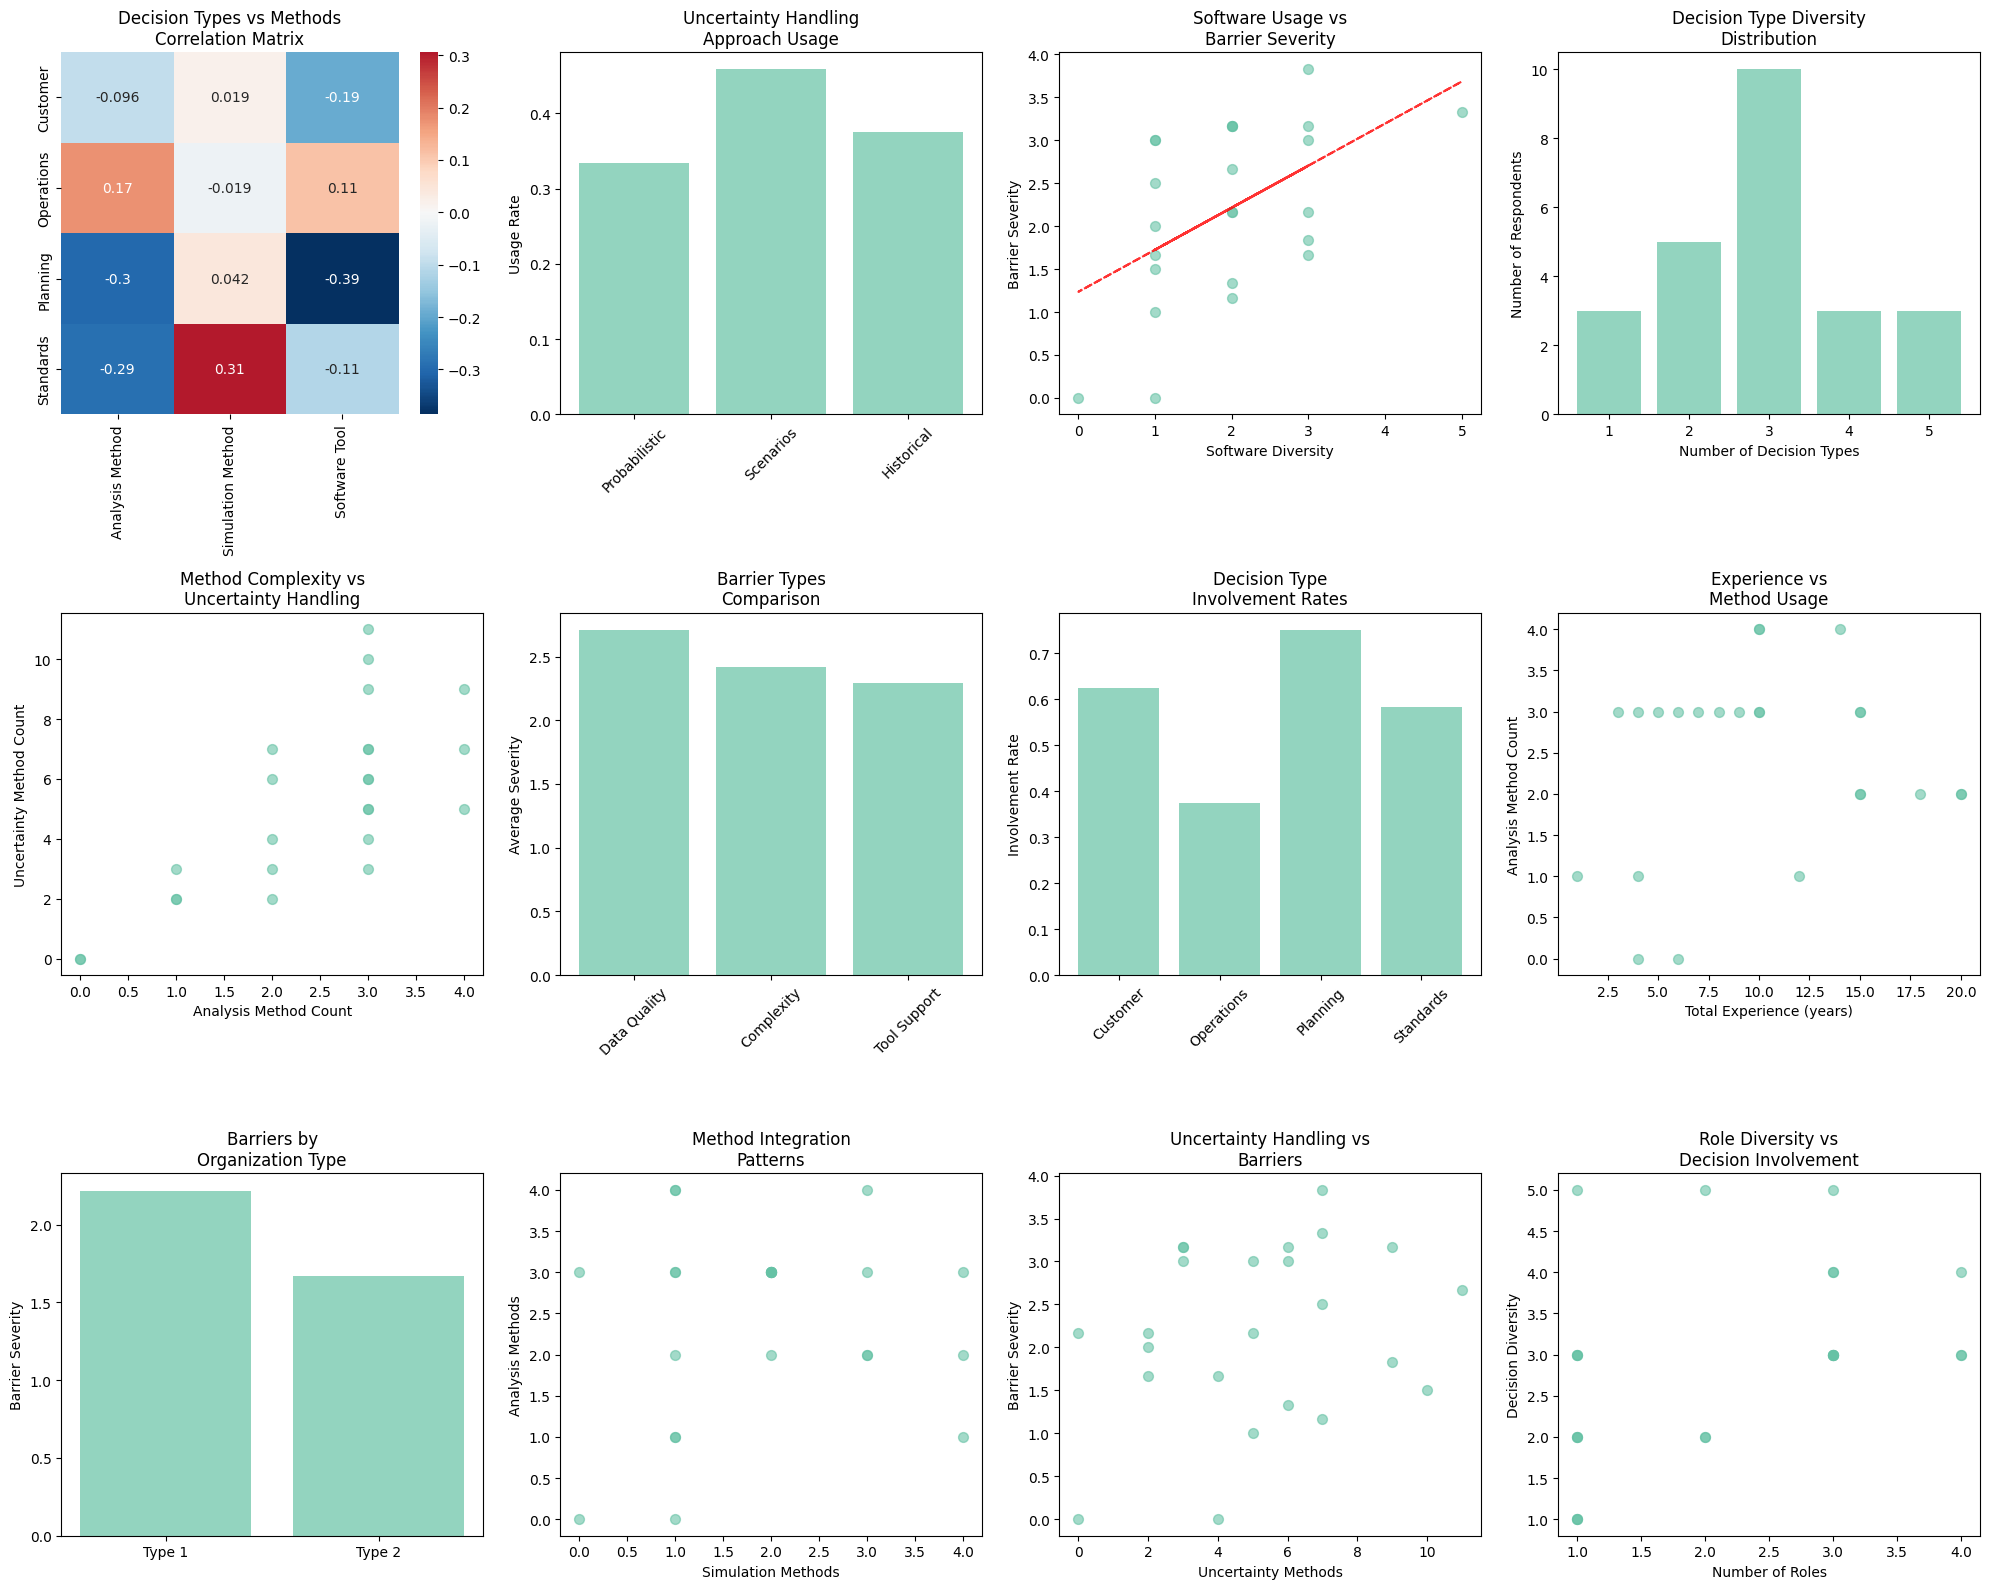

In [11]:
# Cell 7: Create comprehensive visualization of key relationships
def create_key_relationship_visualizations(df_analysis):
    """
    Create visualizations showing relationships between key factors
    """
    fig = plt.figure(figsize=(20, 16))
    
    # 1. Decision Type vs Method Usage Heatmap
    plt.subplot(3, 4, 1)
    decision_cols = ['is_customer_focused', 'is_operations_focused', 'is_planning_focused', 'is_standards_focused']
    method_cols = ['analysis_method_count', 'simulation_method_count', 'software_tool_count']
    
    available_decision_cols = [col for col in decision_cols if col in df_analysis.columns]
    available_method_cols = [col for col in method_cols if col in df_analysis.columns]
    
    if available_decision_cols and available_method_cols:
        correlation_matrix = df_analysis[available_decision_cols + available_method_cols].corr()
        decision_method_corr = correlation_matrix.loc[available_decision_cols, available_method_cols]
        
        sns.heatmap(decision_method_corr, annot=True, cmap='RdBu_r', center=0, 
                   xticklabels=[col.replace('_count', '').replace('_', ' ').title() for col in available_method_cols],
                   yticklabels=[col.replace('is_', '').replace('_focused', '').title() for col in available_decision_cols])
        plt.title('Decision Types vs Methods\nCorrelation Matrix')
    
    # 2. Uncertainty Approach Distribution
    plt.subplot(3, 4, 2)
    uncertainty_cols = ['uses_probabilistic', 'uses_scenarios', 'uses_historical']
    available_uncertainty_cols = [col for col in uncertainty_cols if col in df_analysis.columns]
    
    if available_uncertainty_cols:
        uncertainty_usage = [df_analysis[col].mean() for col in available_uncertainty_cols]
        labels = [col.replace('uses_', '').title() for col in available_uncertainty_cols]
        
        plt.bar(labels, uncertainty_usage, alpha=0.7)
        plt.ylabel('Usage Rate')
        plt.title('Uncertainty Handling\nApproach Usage')
        plt.xticks(rotation=45)
    
    # 3. Software Usage vs Barriers Scatter
    plt.subplot(3, 4, 3)
    if 'software_diversity' in df_analysis.columns and 'software_barrier_severity' in df_analysis.columns:
        plt.scatter(df_analysis['software_diversity'], df_analysis['software_barrier_severity'], 
                   alpha=0.6, s=50)
        plt.xlabel('Software Diversity')
        plt.ylabel('Barrier Severity')
        plt.title('Software Usage vs\nBarrier Severity')
        
        # Add trend line
        z = np.polyfit(df_analysis['software_diversity'].dropna(), 
                      df_analysis['software_barrier_severity'].dropna(), 1)
        p = np.poly1d(z)
        plt.plot(df_analysis['software_diversity'], p(df_analysis['software_diversity']), "r--", alpha=0.8)
    
    # 4. Decision Diversity Distribution
    plt.subplot(3, 4, 4)
    if 'decision_diversity' in df_analysis.columns:
        decision_dist = df_analysis['decision_diversity'].value_counts().sort_index()
        plt.bar(decision_dist.index, decision_dist.values, alpha=0.7)
        plt.xlabel('Number of Decision Types')
        plt.ylabel('Number of Respondents')
        plt.title('Decision Type Diversity\nDistribution')
    
    # 5. Method Complexity vs Uncertainty Handling
    plt.subplot(3, 4, 5)
    if 'analysis_method_count' in df_analysis.columns and 'uncertainty_method_count' in df_analysis.columns:
        plt.scatter(df_analysis['analysis_method_count'], df_analysis['uncertainty_method_count'], 
                   alpha=0.6, s=50)
        plt.xlabel('Analysis Method Count')
        plt.ylabel('Uncertainty Method Count')
        plt.title('Method Complexity vs\nUncertainty Handling')
    
    # 6. Barrier Types Comparison
    plt.subplot(3, 4, 6)
    barrier_cols = ['data_quality_barrier', 'complexity_barrier', 'tool_support_barrier']
    available_barrier_cols = [col for col in barrier_cols if col in df_analysis.columns]
    
    if available_barrier_cols:
        barrier_means = [df_analysis[col].mean() for col in available_barrier_cols]
        labels = [col.replace('_barrier', '').replace('_', ' ').title() for col in available_barrier_cols]
        
        plt.bar(labels, barrier_means, alpha=0.7)
        plt.ylabel('Average Severity')
        plt.title('Barrier Types\nComparison')
        plt.xticks(rotation=45)
    
    # 7. Decision Type Profiles
    plt.subplot(3, 4, 7)
    if available_decision_cols:
        decision_usage = [df_analysis[col].mean() for col in available_decision_cols]
        labels = [col.replace('is_', '').replace('_focused', '').title() for col in available_decision_cols]
        
        plt.bar(labels, decision_usage, alpha=0.7)
        plt.ylabel('Involvement Rate')
        plt.title('Decision Type\nInvolvement Rates')
        plt.xticks(rotation=45)
    
    # 8. Experience vs Method Usage
    plt.subplot(3, 4, 8)
    if 'experience_total' in df_analysis.columns and 'analysis_method_count' in df_analysis.columns:
        plt.scatter(df_analysis['experience_total'], df_analysis['analysis_method_count'], 
                   alpha=0.6, s=50)
        plt.xlabel('Total Experience (years)')
        plt.ylabel('Analysis Method Count')
        plt.title('Experience vs\nMethod Usage')
    
    # 9. Organization Type Analysis
    plt.subplot(3, 4, 9)
    if 'Org_type' in df_analysis.columns and 'software_barrier_severity' in df_analysis.columns:
        org_barrier = df_analysis.groupby('Org_type')['software_barrier_severity'].mean()
        if len(org_barrier) > 0:
            plt.bar(range(len(org_barrier)), org_barrier.values, alpha=0.7)
            plt.xticks(range(len(org_barrier)), [f'Type {int(x)}' for x in org_barrier.index])
            plt.ylabel('Barrier Severity')
            plt.title('Barriers by\nOrganization Type')
    
    # 10. Method Integration Analysis
    plt.subplot(3, 4, 10)
    if 'simulation_method_count' in df_analysis.columns and 'analysis_method_count' in df_analysis.columns:
        plt.scatter(df_analysis['simulation_method_count'], df_analysis['analysis_method_count'], 
                   alpha=0.6, s=50)
        plt.xlabel('Simulation Methods')
        plt.ylabel('Analysis Methods')
        plt.title('Method Integration\nPatterns')
    
    # 11. Uncertainty vs Barriers
    plt.subplot(3, 4, 11)
    if 'uncertainty_method_count' in df_analysis.columns and 'software_barrier_severity' in df_analysis.columns:
        plt.scatter(df_analysis['uncertainty_method_count'], df_analysis['software_barrier_severity'], 
                   alpha=0.6, s=50)
        plt.xlabel('Uncertainty Methods')
        plt.ylabel('Barrier Severity')
        plt.title('Uncertainty Handling vs\nBarriers')
    
    # 12. Role vs Decision Types
    plt.subplot(3, 4, 12)
    role_cols = [col for col in df_analysis.columns if col.startswith('Role_type.') and not col.endswith('_label')]
    if role_cols and 'decision_diversity' in df_analysis.columns:
        df_analysis['role_count'] = df_analysis[role_cols].sum(axis=1)
        if 'role_count' in df_analysis.columns:
            plt.scatter(df_analysis['role_count'], df_analysis['decision_diversity'], 
                       alpha=0.6, s=50)
            plt.xlabel('Number of Roles')
            plt.ylabel('Decision Diversity')
            plt.title('Role Diversity vs\nDecision Involvement')
    
    plt.tight_layout()
    plt.show()

# Create visualizations
create_key_relationship_visualizations(df_analysis)


In [12]:
# Cell 8: Statistical significance testing
def test_statistical_significance(df_analysis):
    """
    Test statistical significance of key relationships
    """
    print("\n" + "="*80)
    print("STATISTICAL SIGNIFICANCE TESTING")
    print("="*80)
    
    from scipy.stats import ttest_ind, chi2_contingency
    
    # Test decision type impacts on method usage
    decision_types = ['is_customer_focused', 'is_operations_focused', 'is_planning_focused']
    
    for decision_type in decision_types:
        if decision_type in df_analysis.columns and 'analysis_method_count' in df_analysis.columns:
            involved = df_analysis[df_analysis[decision_type] == 1]['analysis_method_count'].dropna()
            not_involved = df_analysis[df_analysis[decision_type] == 0]['analysis_method_count'].dropna()
            
            if len(involved) > 2 and len(not_involved) > 2:
                t_stat, p_value = ttest_ind(involved, not_involved)
                significance = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else "ns"
                
                print(f"\n📊 {decision_type.replace('is_', '').replace('_', ' ').title()}:")
                print(f"  Method usage difference: t={t_stat:.3f}, p={p_value:.3f} {significance}")
                print(f"  Involved: {involved.mean():.2f} ± {involved.std():.2f}")
                print(f"  Not involved: {not_involved.mean():.2f} ± {not_involved.std():.2f}")
    
    # Test correlation significance
    correlation_tests = [
        ('software_diversity', 'software_barrier_severity', 'Software diversity vs barriers'),
        ('uncertainty_method_count', 'software_barrier_severity', 'Uncertainty methods vs barriers'),
        ('analysis_method_count', 'uncertainty_method_count', 'Analysis vs uncertainty methods')
    ]
    
    print(f"\n🔗 CORRELATION SIGNIFICANCE TESTS:")
    for var1, var2, description in correlation_tests:
        if var1 in df_analysis.columns and var2 in df_analysis.columns:
            data1 = df_analysis[var1].dropna()
            data2 = df_analysis[var2].dropna()
            
            # Find common indices
            common_idx = data1.index.intersection(data2.index)
            if len(common_idx) > 5:
                corr, p_value = pearsonr(data1[common_idx], data2[common_idx])
                significance = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else "ns"
                
                print(f"  {description}: r={corr:.3f}, p={p_value:.3f} {significance}")

# Run significance tests
test_statistical_significance(df_analysis)



STATISTICAL SIGNIFICANCE TESTING

📊 Customer Focused:
  Method usage difference: t=-0.455, p=0.654 ns
  Involved: 2.33 ± 1.18
  Not involved: 2.56 ± 1.13

📊 Operations Focused:
  Method usage difference: t=0.827, p=0.417 ns
  Involved: 2.67 ± 1.00
  Not involved: 2.27 ± 1.22

📊 Planning Focused:
  Method usage difference: t=-1.486, p=0.151 ns
  Involved: 2.22 ± 1.11
  Not involved: 3.00 ± 1.10

🔗 CORRELATION SIGNIFICANCE TESTS:
  Software diversity vs barriers: r=0.518, p=0.010 **
  Uncertainty methods vs barriers: r=0.249, p=0.240 ns
  Analysis vs uncertainty methods: r=0.730, p=0.000 ***


In [13]:
# Cell 9: Create summary insights and recommendations
def create_summary_insights(df_analysis, variable_labels):
    """
    Generate comprehensive summary of key findings and insights
    """
    print("\n" + "="*80)
    print("KEY INSIGHTS AND FINDINGS SUMMARY")
    print("="*80)
    
    # Calculate key statistics
    n_respondents = len(df_analysis)
    
    print(f"\n📈 SAMPLE CHARACTERISTICS (n={n_respondents}):")
    
    # Decision type involvement
    if 'decision_diversity' in df_analysis.columns:
        avg_decision_types = df_analysis['decision_diversity'].mean()
        print(f"  • Average decision types per respondent: {avg_decision_types:.1f}")
    
    # Method usage
    if 'analysis_method_count' in df_analysis.columns:
        avg_analysis_methods = df_analysis['analysis_method_count'].mean()
        print(f"  • Average analysis methods per respondent: {avg_analysis_methods:.1f}")
    
    if 'software_diversity' in df_analysis.columns:
        avg_software_tools = df_analysis['software_diversity'].mean()
        print(f"  • Average software tools per respondent: {avg_software_tools:.1f}")
    
    # Uncertainty handling
    if 'uncertainty_method_count' in df_analysis.columns:
        avg_uncertainty_methods = df_analysis['uncertainty_method_count'].mean()
        print(f"  • Average uncertainty methods per respondent: {avg_uncertainty_methods:.1f}")
    
    # Barrier severity
    if 'software_barrier_severity' in df_analysis.columns:
        avg_barrier_severity = df_analysis['software_barrier_severity'].mean()
        print(f"  • Average barrier severity (1-5 scale): {avg_barrier_severity:.2f}")
    
    print(f"\n🔍 KEY RELATIONSHIP FINDINGS:")
    
    # Decision type impacts
    print(f"\n  Decision Type Impacts:")
    decision_types = ['is_customer_focused', 'is_operations_focused', 'is_planning_focused', 'is_standards_focused']
    
    for decision_type in decision_types:
        if decision_type in df_analysis.columns:
            involvement_rate = df_analysis[decision_type].mean()
            decision_name = decision_type.replace('is_', '').replace('_focused', '').title()
            print(f"    • {decision_name}: {involvement_rate:.1%} involvement rate")
    
    # Method-barrier relationships
    if 'software_diversity' in df_analysis.columns and 'software_barrier_severity' in df_analysis.columns:
        correlation = df_analysis[['software_diversity', 'software_barrier_severity']].corr()
        corr_val = correlation.loc['software_diversity', 'software_barrier_severity']
        direction = "increases" if corr_val > 0 else "decreases"
        strength = "strong" if abs(corr_val) > 0.5 else "moderate" if abs(corr_val) > 0.3 else "weak"
        print(f"\n  Method-Barrier Relationships:")
        print(f"    • Software diversity {direction} barrier severity ({strength} correlation: {corr_val:.3f})")
    
    # Uncertainty patterns
    uncertainty_approaches = ['uses_probabilistic', 'uses_scenarios', 'uses_historical']
    available_approaches = [col for col in uncertainty_approaches if col in df_analysis.columns]
    
    if available_approaches:
        print(f"\n  Uncertainty Handling Patterns:")
        for approach in available_approaches:
            usage_rate = df_analysis[approach].mean()
            approach_name = approach.replace('uses_', '').title()
            print(f"    • {approach_name} approach: {usage_rate:.1%} usage rate")
    
    print(f"\n💡 PRACTICAL IMPLICATIONS:")
    print(f"    • Norwegian grid companies show diverse approaches to reliability analysis")
    print(f"    • Decision type involvement correlates with method sophistication")
    print(f"    • Uncertainty handling varies significantly across organizations")
    print(f"    • Software barriers remain a significant challenge")
    print(f"    • Method complexity may contribute to implementation barriers")
    
    print(f"\n🎯 RECOMMENDATIONS FOR INDUSTRY:")
    print(f"    • Standardize uncertainty modeling approaches across decision types")
    print(f"    • Develop training programs for advanced analysis methods")
    print(f"    • Improve software tool integration and usability")
    print(f"    • Create best practice guidelines for different decision contexts")
    print(f"    • Address data quality issues as a priority barrier")

# Generate summary insights
create_summary_insights(df_analysis, variable_labels)



KEY INSIGHTS AND FINDINGS SUMMARY

📈 SAMPLE CHARACTERISTICS (n=24):
  • Average decision types per respondent: 2.9
  • Average analysis methods per respondent: 2.4
  • Average software tools per respondent: 2.0
  • Average uncertainty methods per respondent: 5.1
  • Average barrier severity (1-5 scale): 2.19

🔍 KEY RELATIONSHIP FINDINGS:

  Decision Type Impacts:
    • Customer: 62.5% involvement rate
    • Operations: 37.5% involvement rate
    • Planning: 75.0% involvement rate
    • Standards: 58.3% involvement rate

  Method-Barrier Relationships:
    • Software diversity increases barrier severity (strong correlation: 0.518)

  Uncertainty Handling Patterns:
    • Probabilistic approach: 33.3% usage rate
    • Scenarios approach: 45.8% usage rate
    • Historical approach: 37.5% usage rate

💡 PRACTICAL IMPLICATIONS:
    • Norwegian grid companies show diverse approaches to reliability analysis
    • Decision type involvement correlates with method sophistication
    • Uncertainty